<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan11_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 11
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

=== Eksplorasi Awal Data ===
Dimensi Dataset: (300, 4)

Statistik Deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


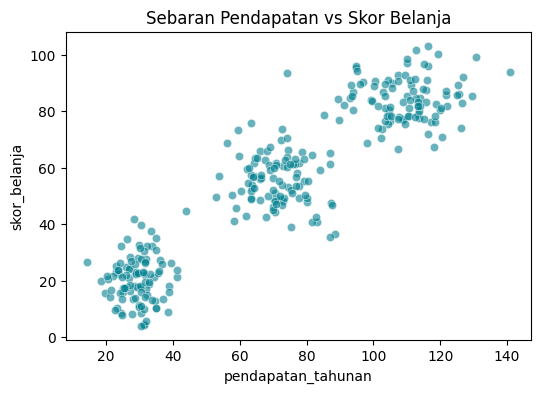


=== Hasil Preprocessing ===
Rata-rata setelah scaling: [-0.  0.]
Std Dev setelah scaling  : [1. 1.]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# =====================================================================
# LANGKAH 1: GENERATE & EKSPLORASI DATASET
# =====================================================================
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # Kelompok 1 (Hemat)
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # Kelompok 2 (Menengah)
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # Kelompok 3 (Premium)

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('=== Eksplorasi Awal Data ===')
print('Dimensi Dataset:', df.shape)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))

# Visualisasi sebaran data mentah
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

# =====================================================================
# LANGKAH 2: PREPROCESSING DATA (FEATURE SCALING)
# =====================================================================
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n=== Hasil Preprocessing ===')
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std Dev setelah scaling  :', X_scaled.std(axis=0).round(3))

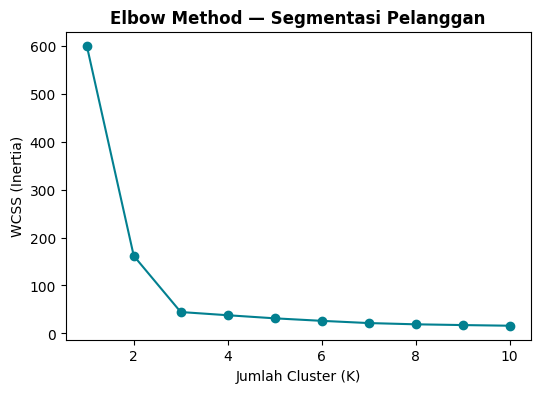

In [2]:
from sklearn.cluster import KMeans

# =====================================================================
# LANGKAH 3: METODE ELBOW UNTUK MENENTUKAN K
# =====================================================================
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090') # fontweight dihapus dari sini
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Segmentasi Pelanggan', fontweight='bold') # Kalau mau bold di judul baru benar
plt.show()

### Analisis Metode Elbow:
* **Titik Melandai (Elbow Point):** Kurva karakteristik *WCSS* mengalami penurunan tajam dan mulai membentuk tekukan melandai (*elbow*) yang konsisten tepat pada titik **K = 3**.
* **Kesesuaian Target:** Hasil pengamatan ini sangat ideal karena berhasil menangkap kembali 3 pola kelompok alami yang sengaja dibuat pada data awal.

=== Evaluasi Model K-Means ===
WCSS Akhir      : 44.556
Silhouette Score: 0.695

Rata-rata Fitur per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


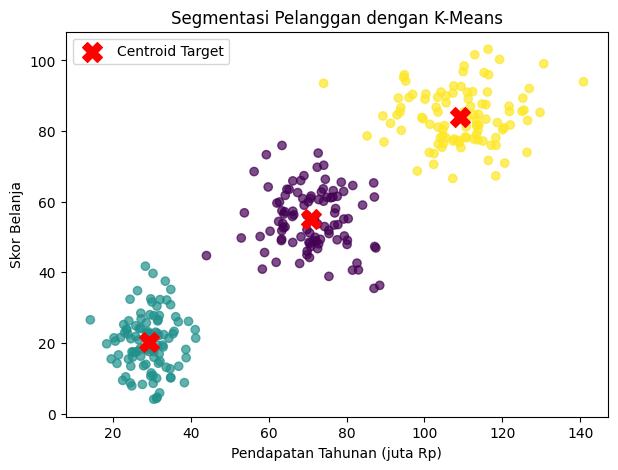

In [3]:
from sklearn.metrics import silhouette_score

# =====================================================================
# LANGKAH 4: MELATIH MODEL K-MEANS (K=3)
# =====================================================================
model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print('=== Evaluasi Model K-Means ===')
print(f'WCSS Akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print('\nRata-rata Fitur per Cluster:')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

# =====================================================================
# LANGKAH 5: VISUALISASI HASIL CLUSTERING
# =====================================================================
# Mengembalikan posisi titik tengah (centroid) ke skala rupiah asli
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'], c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroid Target')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.show()

### Karakteristik Segmen Pelanggan:
* **Cluster 0 (Menengah):** Pendapatan tahunan menengah ($\pm 70.99$ juta Rp) dengan pengeluaran skor belanja menengah ($\pm 55.05$).
* **Cluster 1 (Hemat):** Pendapatan tahunan cenderung rendah ($\pm 29.31$ juta Rp) dengan tingkat skor belanja rendah ($\pm 20.27$).
* **Cluster 2 (Premium / Sultan):** Pendapatan tahunan tinggi ($\pm 109.20$ juta Rp) diimbangi skor belanja yang sangat loyal/tinggi ($\pm 84.08$).

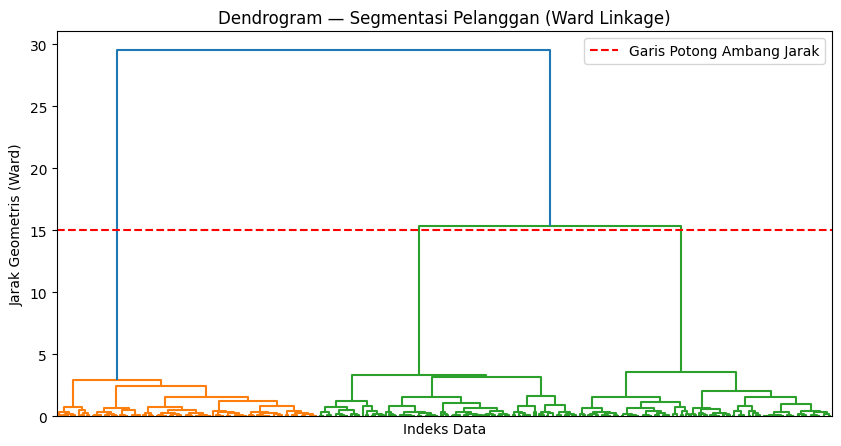

In [4]:
from scipy.cluster.hierarchy import dendrogram, linkage

# =====================================================================
# LANGKAH 6: HIERARCHICAL CLUSTERING (PEMBANDING)
# =====================================================================
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True)  # Menyembunyikan indeks bawah agar grafik rapi
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak Geometris (Ward)')
plt.axhline(y=15, color='red', linestyle='--', label='Garis Potong Ambang Jarak')
plt.legend()
plt.show()

## Kesimpulan

* **Apa yang Dipelajari:** Membangun *pipeline* klasterisasi pelanggan (*Unsupervised Learning*) menggunakan *K-Means* serta memvalidasi struktur kelompoknya melalui diagram herarki *Dendrogram*.
* **Temuan Utama:** Model *K-Means* berhasil mengelompokkan pelanggan ke dalam 3 segmen perilaku (*Hemat*, *Menengah*, *Premium*) dengan struktur pemisahan yang sangat solid, dibuktikan oleh skor *Silhouette* tinggi di angka **0.695**. Ketika divalidasi menggunakan *Hierarchical Clustering*, penempatan garis potong ambang jarak pada level 15 menghasilkan 3 cabang utama yang tegak lurus, membuktikan hasil *K=3* dari Metode *Elbow* teruji sangat konsisten secara matematis.
* **Keterbatasan & Pertanyaan:** * *Keterbatasan:* Eksperimen pengelompokan ini baru memanfaatkan fitur numerik dimensi pendapatan dan pengeluaran saja, belum melibatkan variabel pelengkap lain seperti `usia` atau `gender`.
  * *Pertanyaan:* Bagaimana cara memadukan data campuran numerik dan kategori teks ke dalam algoritma klasterisasi (misalnya menggunakan *K-Prototypes*) agar profil segmen yang dihasilkan bisnis jauh lebih kaya?